In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
df = pd.read_csv('DeepLearning_Original_data.csv')
df.head(5)

,census_year,clue_small_area,Total_cafe,accommodation_and_food_services,administrative_and_support_services,agriculture_forestry_and_fishing,arts_and_recreation_services,construction,education_and_training,electricity_gas_water_and_waste_services,...,other_services,professional_scientific_and_technical_services,public_administration_and_safety,rental_hiring_and_real_estate_services,retail_trade,transport_postal_and_warehousing,wholesale_trade,total_establishments_in_block,Total_Dwel,New_Cafe
0,2002,Carlton,241,190,40,0,31,13,61,13,...,146,143,13,15,166,10,24,1069,80.0,33
1,2002,Docklands,24,23,6,1,9,4,1,6,...,14,7,7,4,11,36,3,147,850.0,26
2,2002,East Melbourne,39,54,22,0,42,4,12,8,...,40,70,14,5,16,6,7,488,78.0,5
3,2002,Kensington,8,12,1,0,60,2,2,4,...,8,6,3,2,7,5,23,169,81.0,0
4,2002,Melbourne (CBD),1072,993,489,7,92,68,143,53,...,605,1343,161,148,1317,129,128,7164,1452.0,0


In [4]:
df.shape

(273, 25)

In [5]:
data = df.iloc[:-1,-1]


In [25]:
from sklearn.svm import SVR
import warnings

In [19]:
def model_svr(parameter, X_train, X_test, y_train, y_test, pred, name):
    warnings.filterwarnings("ignore")
    model = SVR(kernel =parameter)
    model.fit(X_train, y_train)
    print(X_train.shape)
    print(X_test.shape)
    print(y_train.shape)
    print(y_test.shape)
    y_pred = model.predict(X_test)

    mse =mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test,y_pred)
    print('Mean Suqared Error:',mse)
    print('R-squared',r2)
    
    value_2022 = model.predict(pred)
    if value_2022 < 0:
        value_2022 = 0
    else:
        value_2022 = value_2022.astype(int)
    print(f'The predicted number of new cafe in {name} is {value_2022}')
    plt.scatter(range(len(y_test)), y_test, color ='blue', label='Actual')
    plt.scatter(range(len(y_pred)), y_pred, color= 'red', label ='Predicted')
    plt.legend()
    plt.show()

In [8]:
def model_svr_pred(parameter, X_train, X_test, y_train, y_test, pred, name):
    warnings.filterwarnings("ignore")
    model = SVR(kernel =parameter, )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse =mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test,y_pred)

    
    value_2022 = model.predict(pred)
    if value_2022 < 0:
        value_2022 = 0
    else:
        value_2022 = value_2022.astype(int)
    print('****-----****')
    print(f'The predicted number of new cafe in {name} is {value_2022}')
    print('Mean Suqared Error:',mse)
    print('R-squared',r2)
    return value_2022 ,mse, r2

In [21]:
def suburb_data(data, name):
    X_train = data.loc[(df['census_year']<2013)&(df['clue_small_area']==name),:].drop(columns=['census_year','clue_small_area','Total_cafe'])
    y_train = data.loc[(df['census_year']<2013)&(df['clue_small_area']==name),['Total_cafe']].values

    X_test= data.loc[(df['census_year']>2012)&(df['census_year']<2019)&(df['clue_small_area']==name),:].drop(columns=['census_year','clue_small_area','Total_cafe'])
    y_test = data.loc[(df['census_year']>2012)&(df['census_year']<2019)&(df['clue_small_area']==name),['Total_cafe']].values

    pred = data.loc[(df['census_year']==2019)&(df['clue_small_area']==name),:].drop(columns=['census_year','clue_small_area','Total_cafe'])

    name = name
    return X_train, y_train,X_test,y_test,pred,name

In [13]:
def suburb_data_scaled(data, name):
    X_train = data.loc[(df['census_year']<2015)&(df['clue_small_area']==name),:].drop(columns=['census_year','clue_small_area','Total_cafe'])
    y_train = data.loc[(df['census_year']<2015)&(df['clue_small_area']==name),['Total_cafe']].values
    
    X_test= data.loc[(df['census_year']>2015)&(df['census_year']<2022)&(df['clue_small_area']==name),:].drop(columns=['census_year','clue_small_area','Total_cafe'])
    y_test = data.loc[(df['census_year']>2015)&(df['census_year']<2022)&(df['clue_small_area']==name),['Total_cafe']].values

    pred = data.loc[(df['census_year']==2022)&(df['clue_small_area']==name),:].drop(columns=['census_year','clue_small_area','Total_cafe'])

    name = name
    return X_train, y_train,X_test,y_test,pred,name

In [38]:
df['clue_small_area'].unique()

array(['Carlton', 'Docklands', 'East Melbourne', 'Kensington',
       'Melbourne (CBD)', 'Melbourne (Remainder)', 'North Melbourne',
       'Parkville', 'Port Melbourne', 'South Yarra', 'Southbank',
       'West Melbourne (Industrial)', 'West Melbourne (Residential)'],
      dtype=object)

In [40]:
CX_train, CY_train, CX_test, CY_test, Cpred ,Cname= suburb_data(df,'Melbourne (CBD)')

(11, 22)
(6, 22)
(11, 1)
(6, 1)
Mean Suqared Error: 224854.34889887762
R-squared -92.69364971016707
The predicted number of new cafe in Melbourne (CBD) is [2063]


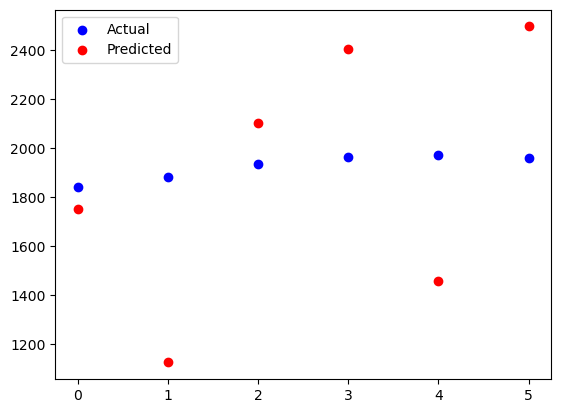

In [41]:
model_svr('linear',CX_train, CX_test,CY_train, CY_test, Cpred, Cname)

https://www.geeksforgeeks.org/svm-hyperparameter-tuning-using-gridsearchcv-ml/
<BR> Need to perform tunning

In [42]:
# Model Tunning
from sklearn.model_selection import GridSearchCV 
  
# defining parameter range 
param_grid = {'C': [0.1, 0.2,1.2,2.3, 10,11,15],  
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
              'kernel': ['rbf','linear']}  
  
grid = GridSearchCV(SVR(), param_grid, refit = True, verbose = 3) 
  
# fitting the model for grid search 
grid.fit(CX_train, CY_train) 

Fitting 5 folds for each of 70 candidates, totalling 350 fits
[CV 1/5] END ......C=0.1, gamma=1, kernel=rbf;, score=-31.840 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=1, kernel=rbf;, score=-14.848 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-3.166 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=1, kernel=rbf;, score=-25.649 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=1, kernel=rbf;, score=-429.722 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=1, kernel=linear;, score=-2.605 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.157 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.700 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.680 total time=   0.0s
[CV 5/5] END ..C=0.1, gamma=1, kernel=linear;, score=-289.753 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=0.1, kernel=rbf;, score=-31.840 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=0.1, kernel=rbf;,

GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.1, 0.2, 1.2, 2.3, 10, 11, 15],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'linear']},
             verbose=3)

In [43]:
print(grid.best_params_) 
  
# print how our model looks after hyper-parameter tuning 
print(grid.best_estimator_) 

{'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
SVR(C=0.1, gamma=1, kernel='linear')


In [44]:
def model_svr_best(c,gamma,parameter, X_train, X_test, y_train, y_test, pred, name):
    warnings.filterwarnings("ignore")
    model = SVR(C=c, gamma= gamma,kernel =parameter)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse =mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test,y_pred)
    print('Mean Suqared Error:',mse)
    print('R-squared',r2)
    
    value_2022 = model.predict(pred)
    if value_2022 < 0:
        value_2022 = 0
    else:
        value_2022 = value_2022.astype(int)
    print(f'The predicted number of new cafe in {name} is {value_2022}')
    plt.scatter(range(len(y_test)), y_test, color ='blue', label='Actual')
    plt.scatter(range(len(y_pred)), y_pred, color= 'red', label ='Predicted')
    plt.legend()
    plt.show()

Mean Suqared Error: 224854.34889887762
R-squared -92.69364971016707
The predicted number of new cafe in Melbourne (CBD) is [2063]


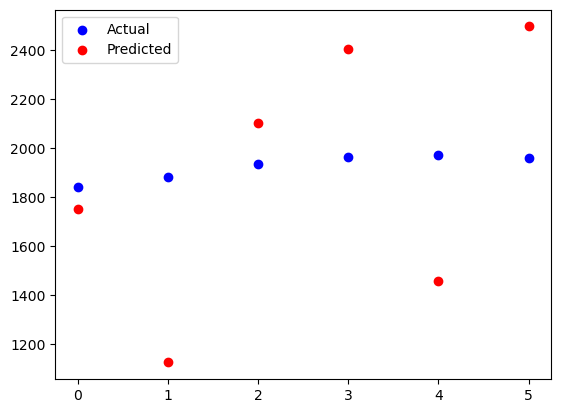

In [52]:
CX_train, CY_train, CX_test, CY_test, Cpred ,Cname= suburb_data(df,'Melbourne (CBD)')
model_svr_best(10,100,'linear',CX_train, CX_test,CY_train, CY_test, Cpred, Cname)

Mean Suqared Error: 68.19749999999999
R-squared -0.6165333333333332
The predicted number of new cafe in Docklands is [8]


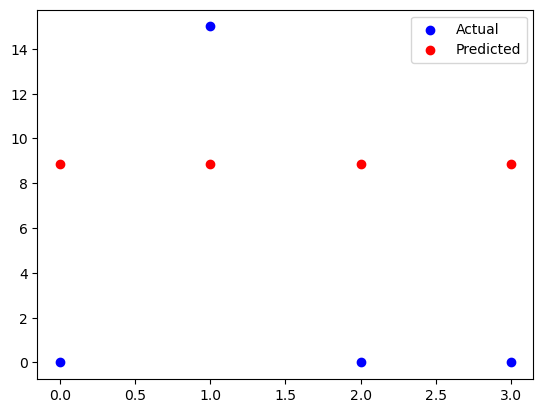

In [214]:
CX_train, CY_train, CX_test, CY_test, Cpred ,Cname= suburb_data(df,'Docklands')
model_svr_best(10,1,'rbf',CX_train, CX_test,CY_train, CY_test, Cpred, Cname)